In [1]:
import concurrent.futures
import multiprocessing
import pathlib
import re
import os
import sys

from IPython.display import display, Markdown
import matplotlib.pyplot
import numpy
import polars
from tqdm.notebook import tqdm

from list_scenarios import list_scenarios_full

EVALUATION_DIR = pathlib.Path.cwd()
INPUT_PATH = EVALUATION_DIR / "output_dataset"


os.environ["INPUT_PATH"] = str(INPUT_PATH)

# Dataset Exploration

## Calculate Statistics

In [2]:
def stat_scenario(scenario, prot, l2, stp, l2_mode, data, dns, blk, _):
    eth_csv = INPUT_PATH / f"{scenario}.wpan.eth.csv.gz"
    app_csv = INPUT_PATH / f"{scenario}.wpan.{'http' if scenario.startswith('https') else 'coap'}.csv.gz"
    training_csv = INPUT_PATH / f"{scenario}.training.csv.gz"
    eth_lf = polars.scan_csv(eth_csv, separator="\t").with_columns(
        (polars.col("eth.payload").str.len_chars() // 2).alias("eth.payload length"),
        (polars.col("eth.payload").str.head(2).is_in(["17", "18"]) & ("-schc-" in scenario)).alias("is_schc_fragment"),
    ).select("frame.number", "eth.src", "eth.dst", "eth.payload length", "is_schc_fragment")
    lf = eth_lf.join(
        polars.scan_csv(
            app_csv,
            separator="\t",
            schema_overrides={"coap.token": polars.String},
        ),
        on="frame.number",
    )
    training_lf = polars.scan_csv(training_csv, separator=";").select(
        ["frame.number", "client.type"]
    )
    data_frames = training_lf.filter(
        polars.col("client.type") == "data"
    ).select("frame.number").collect()["frame.number"].to_list()
    dns_frames = training_lf.filter(
        polars.col("client.type") == "dns"
    ).select("frame.number").collect()["frame.number"].to_list()
    if app_csv.name.endswith(".http.csv.gz"):
        lf = lf.with_columns(
            polars.when(
                polars.col(
                    "http2.streamid"
                ).str.split(",").list.eval(
                    polars.element() == "0"
                ).list.all()
            ).then(
                0
            ).otherwise(
                polars.col(
                    "http2.streamid"
                ).str.split(",").list.unique().list.eval(
                    polars.element().str.to_integer()
                ).list.sum()
            ).alias("http2.streamid")
        )
        client_addrs = polars.Series(
            lf.filter(
                polars.col("http2.request_in").is_not_null()
            ).select("eth.dst").unique().collect()
        ).to_list()
        dns_streams = polars.Series(
            lf.filter(
                polars.col("frame.number").is_in(dns_frames)
            ).select("http2.streamid").unique().collect()
        ).to_list()
        data_streams = polars.Series(
            lf.filter(
                polars.col("frame.number").is_in(data_frames)
            ).select("http2.streamid").unique().collect()
        ).to_list()
        lf = lf.with_columns(
            (
                polars.col("eth.src").is_in(client_addrs)
                & polars.col("frame.protocols").str.contains("http2")
            ).alias("is_request"),
            (
                polars.col("eth.dst").is_in(client_addrs)
                & polars.col("frame.protocols").str.contains("http2")
            ).alias("is_response"),
            (
                polars.zeros(lf.select(polars.len()).collect()[0, 0]) > 0
            ).alias("is_block"),
            (
                polars.col("http2.streamid").is_in(dns_streams)
            ).alias("is_dns"),
            (
                polars.col("http2.streamid").is_in(data_streams)
            ).alias("is_data"),
        )
        del data_streams
        del dns_streams
    elif app_csv.name.startswith("oscore"):
        if "-p1_" in app_csv.name or "-p2_" in app_csv.name:
            upstream_csv = INPUT_PATH / f"{scenario}.upstream.coap.csv.gz"
            proxy_log = INPUT_PATH / f"{scenario}.proxy.log.gz"
            upstream_lf = polars.scan_csv(
                upstream_csv,
                separator="\t",
                schema_overrides={"coap.token": polars.String},
            ).select(
                ["coap.code", "coap.token", "oscore.opt.block_size"],
            )
            upstream_lf = upstream_lf.join(
                polars.scan_csv(
                    proxy_log,
                    separator="\t",
                    schema_overrides={
                        "old_token": polars.String,
                        "new_token": polars.String,
                    },
                ),
                left_on="coap.token",
                right_on="new_token",
                how="left",
            ).with_columns(
                (numpy.right_shift(polars.col("coap.code"), 5) == 0).alias("is_request"),
            )
            lf = lf.with_columns(
                (numpy.right_shift(polars.col("coap.code"), 5) == 0).alias("is_request"),
            )
            frames_with_upstream_block_opt = upstream_lf.filter(
                polars.col("oscore.opt.block_size").is_not_null()
            ).select("old_token", "is_request").join(
                lf,
                left_on=["old_token", "is_request"],
                right_on=["coap.token", "is_request"],
                how="left",
            ).select("frame.number").unique().collect()["frame.number"].to_list()
        else:
            frames_with_upstream_block_opt = []
        lf = lf.with_columns(
            (numpy.right_shift(polars.col("coap.code"), 5) == 0).alias("is_request"),
            (numpy.right_shift(polars.col("coap.code"), 5) != 0).alias("is_response"),
            polars.col("frame.number").is_in(dns_frames).alias("is_dns"),
            polars.col("frame.number").is_in(data_frames).alias("is_data"),
        ).with_columns(
            (
                polars.col("coap.opt.block_size").is_not_null()
                | polars.col("oscore.opt.block_size").is_not_null()
                | polars.col("frame.number").is_in(
                    frames_with_upstream_block_opt
                )
            ).alias("is_block"),
        )
    else:
        lf = lf.with_columns(
            (numpy.right_shift(polars.col("coap.code"), 5) == 0).alias("is_request"),
            (numpy.right_shift(polars.col("coap.code"), 5) != 0).alias("is_response"),
            (
                polars.col("coap.opt.block_size").is_not_null()
            ).alias("is_block"),
            polars.col("frame.number").is_in(dns_frames).alias("is_dns"),
            polars.col("frame.number").is_in(data_frames).alias("is_data"),
        )
    del dns_frames
    del data_frames
    
    def _kde_method(X, coords):
        X = matplotlib.cbook._unpack_to_numpy(X)
        return matplotlib.mlab.GaussianKDE(X, None).evaluate(coords)
    
    all_len_stats = matplotlib.cbook.violin_stats(
        lf.select("eth.payload length").collect(),
        _kde_method,
        points=100,
        quantiles=[0.05, 0.25, 0.75, 0.95]
    )[0]
    dns_len_stats = matplotlib.cbook.violin_stats(
        lf.filter(polars.col("is_dns")).select("eth.payload length").collect(),
        _kde_method,
        points=100,
        quantiles=[0.05, 0.25, 0.75, 0.95]
    )[0]
    data_len_stats = matplotlib.cbook.violin_stats(
        lf.filter(polars.col("is_data")).select("eth.payload length").collect(),
        _kde_method,
        points=100,
        quantiles=[0.05, 0.25, 0.75, 0.95]
    )[0]
    lf = lf.select("eth.payload length", "is_schc_fragment", "is_request", "is_response", "is_block", "is_dns", "is_data")
    df = polars.DataFrame(
        [
            {
                "scenario": scenario,
                "protocol": prot,
                "l2": "schc" if l2 == "-schc" else "eth",
                "l2_mode": l2_mode.strip("-") if l2_mode else "none",
                "setup": stp,
                "data format": data,
                "DNS format": dns,
                "blocksize": 64 if blk else 1024,
                "SCHC fragments": lf.filter(polars.col("is_schc_fragment")).select("is_schc_fragment").count().first().collect().item(),
                "DNS SCHC fragments": lf.filter(polars.col("is_schc_fragment") & polars.col("is_dns")).select("is_schc_fragment").count().first().collect().item(),
                "data SCHC fragments": lf.filter(polars.col("is_schc_fragment") & polars.col("is_data")).select("is_schc_fragment").count().first().collect().item(),
                "blockwise frames": lf.filter(polars.col("is_block")).select("is_block").count().first().collect().item(),
                "blockwise DNS frames": lf.filter(polars.col("is_block") & polars.col("is_dns")).select("is_block").count().first().collect().item(),
                "blockwise data frames": lf.filter(polars.col("is_block") & polars.col("is_data")).select("is_block").count().first().collect().item(),
                "blockwise SCHC fragments": lf.filter(polars.col("is_block") & polars.col("is_schc_fragment")).select("is_block").count().first().collect().item(),
                "blockwise DNS SCHC fragments": lf.filter(polars.col("is_block") & polars.col("is_schc_fragment") & polars.col("is_dns")).select("is_block").count().first().collect().item(),
                "blockwise data SCHC fragments": lf.filter(polars.col("is_block") & polars.col("is_schc_fragment") & polars.col("is_data")).select("is_block").count().first().collect().item(),
                "frames": lf.select("eth.payload length").count().first().collect().item(),
                "requests": lf.filter(polars.col("is_request")).select("is_request").count().first().collect().item(),
                "responses": lf.filter(polars.col("is_response")).select("is_response").count().first().collect().item(),
                "DNS frames": lf.filter(polars.col("is_dns")).select("is_dns").count().first().collect().item(),
                "data frames": lf.filter(polars.col("is_data")).select("is_data").count().first().collect().item(),
                "other frames": lf.filter(~polars.col("is_data") & ~polars.col("is_dns")).select("is_data").count().first().collect().item(),
                "DNS requests": lf.filter(polars.col("is_request") & polars.col("is_dns")).select("is_request").count().first().collect().item(),
                "DNS responses": lf.filter(polars.col("is_response") & polars.col("is_dns")).select("is_response").count().first().collect().item(),
                "data requests": lf.filter(polars.col("is_request") & polars.col("is_data")).select("is_request").count().first().collect().item(),
                "data responses": lf.filter(polars.col("is_response") & polars.col("is_data")).select("is_response").count().first().collect().item(),
                "other requests": lf.filter(polars.col("is_request") & ~polars.col("is_data") & ~polars.col("is_dns")).select("is_request").count().first().collect().item(),
                "other responses": lf.filter(polars.col("is_response") & ~polars.col("is_data") & ~polars.col("is_dns")).select("is_response").count().first().collect().item(),
                "all lengths mean": all_len_stats["mean"],
                "all lengths std": lf.select("eth.payload length").std().collect().item(),
                "all lengths min": all_len_stats["min"],
                "all lengths q.05": all_len_stats["quantiles"][0],
                "all lengths q.25": all_len_stats["quantiles"][1],
                "all lengths median": all_len_stats["median"],
                "all lengths q.75": all_len_stats["quantiles"][2],
                "all lengths q.95": all_len_stats["quantiles"][3],
                "all lengths max": all_len_stats["max"],
                "all lengths violin coords": all_len_stats["coords"].tolist(),
                "all lengths violin vals": all_len_stats["vals"].tolist(),
                "DNS lengths mean": dns_len_stats["mean"],
                "DNS lengths std": lf.filter(polars.col("is_dns")).select("eth.payload length").std().collect().item(),
                "DNS lengths min": dns_len_stats["min"],
                "DNS lengths q.05": dns_len_stats["quantiles"][0],
                "DNS lengths q.25": dns_len_stats["quantiles"][1],
                "DNS lengths median": dns_len_stats["median"],
                "DNS lengths q.75": dns_len_stats["quantiles"][2],
                "DNS lengths q.95": dns_len_stats["quantiles"][3],
                "DNS lengths max": dns_len_stats["max"],
                "DNS lengths violin coords": dns_len_stats["coords"].tolist(),
                "DNS lengths violin vals": dns_len_stats["vals"].tolist(),
                "data lengths mean": data_len_stats["mean"],
                "data lengths std": lf.filter(polars.col("is_data")).select("eth.payload length").std().collect().item(),
                "data lengths min": data_len_stats["min"],
                "data lengths q.05": data_len_stats["quantiles"][0],
                "data lengths q.25": data_len_stats["quantiles"][1],
                "data lengths median": data_len_stats["median"],
                "data lengths q.75": data_len_stats["quantiles"][2],
                "data lengths q.95": data_len_stats["quantiles"][3],
                "data lengths max": data_len_stats["max"],
                "data lengths violin coords": data_len_stats["coords"].tolist(),
                "data lengths violin vals": data_len_stats["vals"].tolist(),
            }
        ]
    )
    del eth_lf
    del lf
    return df


res = None

workers = multiprocessing.cpu_count()

if workers > 96:
    workers = 96


scenarios = list(list_scenarios_full(filter_randiv_pad=True))


with concurrent.futures.ProcessPoolExecutor(max_workers=workers) as pool:
    def _stat_scenario(args):
        return stat_scenario(*args)
    for df in tqdm(pool.map(_stat_scenario, scenarios), total=len(scenarios)):
        if res is None:
            res = df
        else:
            new = polars.concat([res, df])
            del res
            del df
            res = new
res = res.sort("scenario")
display(res)
res.write_parquet(INPUT_PATH / "stats.parquet", compression="lz4")
res.select(
    [c for c in res.columns if not c.endswith("coords") and not c.endswith("vals")]
).write_csv(INPUT_PATH / "stats.csv")
del res

  0%|          | 0/296 [00:00<?, ?it/s]

scenario,protocol,l2,l2_mode,setup,data format,DNS format,blocksize,SCHC fragments,DNS SCHC fragments,data SCHC fragments,blockwise frames,blockwise DNS frames,blockwise data frames,blockwise SCHC fragments,blockwise DNS SCHC fragments,blockwise data SCHC fragments,frames,requests,responses,DNS frames,data frames,other frames,DNS requests,DNS responses,data requests,data responses,other requests,other responses,all lengths mean,all lengths std,all lengths min,all lengths q.05,all lengths q.25,all lengths median,all lengths q.75,all lengths q.95,all lengths max,all lengths violin coords,all lengths violin vals,DNS lengths mean,DNS lengths std,DNS lengths min,DNS lengths q.05,DNS lengths q.25,DNS lengths median,DNS lengths q.75,DNS lengths q.95,DNS lengths max,DNS lengths violin coords,DNS lengths violin vals,data lengths mean,data lengths std,data lengths min,data lengths q.05,data lengths q.25,data lengths median,data lengths q.75,data lengths q.95,data lengths max,data lengths violin coords,data lengths violin vals
str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,f64,f64,f64,f64,f64,i64,list[f64],list[f64],f64,f64,i64,f64,f64,f64,f64,f64,i64,list[f64],list[f64],f64,f64,i64,f64,f64,f64,f64,f64,i64,list[f64],list[f64]
"""coap-d1_cbor_dns_cbor""","""coap""","""eth""","""none""","""d1""","""cbor""","""dns_cbor""",1024,0,0,0,0,0,0,0,0,0,235068,117534,117534,117534,117534,0,58767,58767,58767,58767,0,0,159.043672,133.139005,58,75.0,102.0,117.0,152.0,415.0,1088,"[58.0, 68.40404, … 1088.0]","[0.001781, 0.004181, … 0.000064]",124.963219,37.932079,72,80.0,107.0,115.0,133.0,207.0,446,"[72.0, 75.777778, … 446.0]","[0.001905, 0.005984, … 9.2421e-7]",193.124126,178.017761,58,69.0,91.0,131.0,205.0,619.0,1088,"[58.0, 68.40404, … 1088.0]","[0.003474, 0.005488, … 0.000085]"
"""coap-d1_cbor_dns_cbor_b64""","""coap""","""eth""","""none""","""d1""","""cbor""","""dns_cbor""",64,0,0,0,628934,185421,443513,0,0,0,672851,336426,336425,209476,463375,0,104738,104738,231688,231687,0,0,106.598416,29.798653,57,58.0,80.0,113.0,124.0,152.0,693,"[57.0, 63.424242, … 693.0]","[0.011205, 0.002796, … 2.9133e-7]",99.907144,22.439996,57,70.0,71.0,109.0,123.0,124.0,140,"[57.0, 57.838384, … 140.0]","[0.001035, 0.001292, … 0.001028]",109.623312,32.130168,57,58.0,83.0,119.0,124.0,157.0,693,"[57.0, 63.424242, … 693.0]","[0.01409, 0.003232, … 3.6413e-7]"
"""coap-d1_cbor_dns_message""","""coap""","""eth""","""none""","""d1""","""cbor""","""dns_message""",1024,0,0,0,0,0,0,0,0,0,235071,117536,117535,117536,117535,0,58768,58768,58768,58767,0,0,176.918676,132.244684,58,75.0,120.0,134.0,193.0,419.0,1088,"[58.0, 68.40404, … 1088.0]","[0.001502, 0.003073, … 0.000065]",160.782705,52.602627,101,120.0,128.0,135.0,187.0,264.0,557,"[101.0, 105.606061, … 557.0]","[0.000115, 0.000652, … 6.6645e-7]",193.054784,178.016292,58,69.0,91.0,131.0,205.0,619.0,1088,"[58.0, 68.40404, … 1088.0]","[0.003487, 0.0055, … 0.000085]"
"""coap-d1_cbor_dns_message_b64""","""coap""","""eth""","""none""","""d1""","""cbor""","""dns_message""",64,0,0,0,767664,324153,443511,0,0,0,792871,396436,396435,329498,463373,0,164749,164749,231687,231686,0,0,106.125148,30.672945,57,58.0,76.0,117.0,125.0,148.0,693,"[57.0, 63.424242, … 693.0]","[0.011951, 0.003113, … 2.4819e-7]",101.144644,27.746662,57,65.0,72.0,114.0,125.0,136.0,141,"[57.0, 57.848485, … 141.0]","[0.006257, 0.006943, … 0.007295]",109.666713,32.128052,57,58.0,83.0,119.0,124.0,157.0,693,"[57.0, 63.424242, … 693.0]","[0.014017, 0.003271, … 3.6415e-7]"
"""coap-d1_json_dns_cbor""","""coap""","""eth""","""none""","""d1""","""json""","""dns_cbor""",1024,0,0,0,0,0,0,0,0,0,235068,117534,117534,117534,117534,0,58767,58767,58767,58767,0,0,168.144371,153.028029,58,76.0,104.0,118.0,158.0,463.0,1090,"[58.0, 68.424242, … 1090.0]","[0.001711, 0.003861, … 0.000063]",125.096032,37.925937,72,80.0,107.0,116.0,133.0,207.0,446,"[72.0, 75.777778, … 446.0]","[0.001791, 0.00583, … 9.2436e-7]",211.19271,20

## Load Pre-Calculated Data for Fain-grained Plotting

In [3]:
df = polars.read_parquet(INPUT_PATH / "stats.parquet")
df = df.with_columns(
    [
        polars.col("protocol").map_elements(
            ["https", "coap", "coaps", "oscore-base", "oscore"].index,
            return_dtype=polars.Int8,
        ).alias("protocol_score"),
        polars.col("l2_mode").map_elements(
            ["none", "min-rules", "peer-based"].index,
            return_dtype=polars.Int8,
        ).alias("l2_mode_score"),
    ]
).sort(
    ["l2", "blocksize", "protocol_score", "data format", "DNS format", "setup", "l2_mode_score"],
).select(df.columns)

## Fine-grained Plot

In [4]:
L2_READABLE = {
    "eth": "Not constrained",
    "schc": "SCHC",
}
PROTOCOLS_READABLE = {
    "coap": "CoAP",
    "coaps": "CoAPS",
    "https": "HTTPS",
    "oscore-base": "OSCORE",
    "oscore_base": "OSCORE",
    "oscore": "Onion OSCORE",
}
DATA_READABLE = {
    "json": "JSON",
    "cbor": "CBOR",
}
DNS_READABLE = {
    "dns_message": "DNS",
    "dns_cbor": "CBOR",
}
L2_MODE_READABLE = {
    None: "split",
    "min-rules": "min.",
    "peer-based": "peer"
}

def mark_groups(ax, textcolor="black", textalpha=0.5, format_offset=None, prot_offset=None):
    last_prot = None
    last_data = None
    last_dns = None
    labels = []
    if format_offset is None:
        format_offset = {}
    for label in ax.get_xticklabels():
        x, y = label.get_position()
        text = label.get_text()
        match = re.search(
            "(?P<prot>[^-]+(-base)?)-((?P<l2>schc)-)?(?P<stp>[dp][12])"
            "(-(?P<l2_mode>[^_]+))?_(?P<data>(cbor|json))_(?P<dns>dns_[^_]+)"
            "(?P<blk>_b64)?",
            text,
        )
        prot_line_drawn = False
        if last_prot != match["prot"]:
            if last_prot is not None:
                ax.add_line(
                    matplotlib.lines.Line2D(
                        [x - 0.5, x - 0.5],
                        ax.get_ylim(),
                        linewidth=0.5,
                        color="black",
                    )
                )
                prot_line_drawn = True
            if prot_offset is None:
                prot_offset = (1.8e5 if ax.get_ylim()[1] >= 5e5 else 20 if not match["l2"] else 2)
            ax.text(
                x - 0.3,
                ax.get_ylim()[1] - prot_offset,
                PROTOCOLS_READABLE[match["prot"]],
                va="top",
                ha="left",
                color=textcolor,
                alpha=textalpha,
                fontsize="small",
                zorder=100,
            )
        if last_data != match["data"] or last_dns != match["dns"]:
            if last_data is not None and last_dns is not None and not prot_line_drawn:
                ax.add_line(
                    matplotlib.lines.Line2D(
                        [x - 0.5, x - 0.5],
                        ax.get_ylim(),
                        linestyle="--",
                        linewidth=0.3,
                        color="black",
                    )
                )
            ax.text(
                x - 0.3,
                numpy.array(ax.get_ylim()).mean() + format_offset.get(
                    (match["prot"], match["l2"], match["blk"]),
                    0,
                ),
                f"{DATA_READABLE[match['data']]} \\&\n{DNS_READABLE[match['dns']]}",
                va="center",
                ha="left",
                color=textcolor,
                alpha=textalpha,
                fontsize=5,
            )
        if match["l2"] == "schc" and match['stp'].endswith("2"):
            labels.append((x, f"{L2_MODE_READABLE[match['l2_mode']]} {match['stp'].upper()}"))
        else:
            labels.append((x, f"{match['stp'].upper()}"))
        last_prot = match["prot"]
        last_data = match["data"]
        last_dns = match["dns"]
    ax.set_xticks(*zip(*labels), fontsize=5)

### Frame Lengths

scenario,DNS lengths mean,DNS lengths min,DNS lengths q.25,DNS lengths median,DNS lengths q.75,DNS lengths max,data lengths mean,data lengths min,data lengths q.25,data lengths median,data lengths q.75,data lengths max
str,f64,i64,f64,f64,f64,i64,f64,i64,f64,f64,f64,i64
"""coap-d1_cbor_dns_cbor_b64""",99.251137,57,71.0,109.0,123.0,140,108.358903,57,80.0,113.0,124.0,497
"""coap-d2_cbor_dns_cbor_b64""",98.620152,57,70.0,108.0,122.0,139,108.235572,57,80.0,113.0,124.0,497
"""coap-p1_cbor_dns_cbor_b64""",102.784157,60,77.0,114.0,124.0,167,123.961856,58,92.0,122.0,124.0,1096
"""coap-p2_cbor_dns_cbor_b64""",102.233103,60,76.0,113.0,124.0,166,123.914666,58,92.0,122.0,124.0,1096
"""coap-d1_cbor_dns_message_b64""",100.619059,57,72.0,108.0,125.0,141,108.331999,57,80.0,113.0,124.0,497
"""coap-d2_cbor_dns_message_b64""",100.211491,57,71.0,108.0,125.0,140,108.417724,57,80.0,113.0,124.0,497
"""coap-p1_cbor_dns_message_b64""",106.894971,61,78.0,123.0,125.0,183,123.883385,58,92.0,122.0,124.0,1096
"""coap-p2_cbor_dns_message_b64""",106.533691,61,77.0,123.0,125.0,183,124.015326,58,92.0,122.0,124.0,1096
"""coap-d1_json_dns_cbor_b64""",99.228518,57,71.0,109.0,123.0,140,108.401425,57,80.0,115.0,124.0,497


#### [Not constrained, Blocksize: 64](plots/frame_lengths_eth_64.pdf)

<Figure size 771.671x83.6699 with 0 Axes>

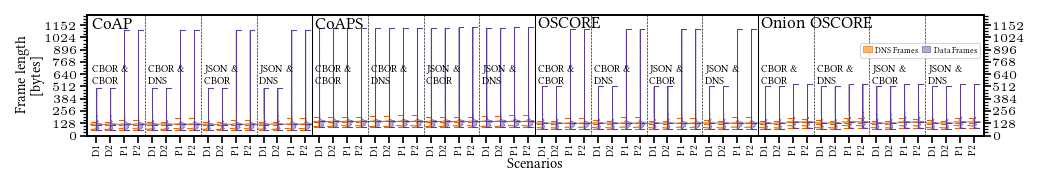

scenario,DNS lengths mean,DNS lengths min,DNS lengths q.25,DNS lengths median,DNS lengths q.75,DNS lengths max,data lengths mean,data lengths min,data lengths q.25,data lengths median,data lengths q.75,data lengths max
str,f64,i64,f64,f64,f64,i64,f64,i64,f64,f64,f64,i64
"""https-d1_cbor_dns_cbor""",180.599603,141,153.0,173.0,189.0,461,238.342749,141,141.0,173.0,221.0,1117
"""https-d2_cbor_dns_cbor""",179.980361,141,153.0,173.0,189.0,461,238.264035,141,141.0,173.0,221.0,1117
"""https-p1_cbor_dns_cbor""",180.596429,141,153.0,173.0,189.0,461,238.351795,141,141.0,173.0,221.0,1117
"""https-p2_cbor_dns_cbor""",180.500893,141,153.0,173.0,189.0,461,238.439411,141,141.0,173.0,221.0,1117
"""https-d1_cbor_dns_message""",197.709383,141,153.0,189.0,221.0,557,238.390835,141,141.0,173.0,221.0,1117
"""https-d2_cbor_dns_message""",196.966356,141,153.0,173.0,221.0,557,238.264035,141,141.0,173.0,221.0,1117
"""https-p1_cbor_dns_message""",197.733347,141,153.0,189.0,221.0,557,238.407657,141,141.0,173.0,221.0,1117
"""https-p2_cbor_dns_message""",197.525451,141,153.0,189.0,221.0,557,238.416068,141,141.0,173.0,221.0,1117
"""https-d1_json_dns_cbor""",180.722119,141,153.0,173.0,189.0,461,252.019718,141,153.0,173.0,237.0,1149


#### [Not constrained, Blocksize: 1024](plots/frame_lengths_eth_1024.pdf)

<Figure size 771.671x104.587 with 0 Axes>

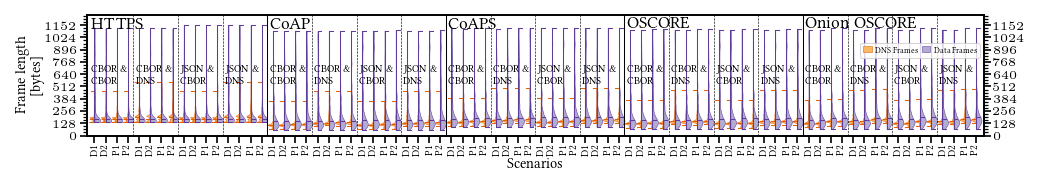

scenario,DNS lengths mean,DNS lengths min,DNS lengths q.25,DNS lengths median,DNS lengths q.75,DNS lengths max,data lengths mean,data lengths min,data lengths q.25,data lengths median,data lengths q.75,data lengths max
str,f64,i64,f64,f64,f64,i64,f64,i64,f64,f64,f64,i64
"""coaps-schc-d1_cbor_dns_cbor_b6…",71.763784,9,43.0,81.0,95.0,127,82.139448,6,59.0,94.0,96.0,127
"""coaps-schc-d2_cbor_dns_cbor_b6…",71.093581,8,42.0,80.0,94.0,127,82.014599,6,59.0,94.0,96.0,127
"""coaps-schc-d2-min-rules_cbor_d…",70.960309,8,42.0,80.0,94.0,127,81.920988,6,58.0,94.0,96.0,127
"""coaps-schc-d2-peer-based_cbor_…",71.061233,8,42.0,80.0,94.0,127,81.99075,6,59.0,94.0,96.0,127
"""coaps-schc-p1_cbor_dns_cbor_b6…",75.079403,8,50.0,86.0,96.0,127,84.424966,6,64.0,95.0,96.0,127
"""coaps-schc-p2_cbor_dns_cbor_b6…",74.678972,8,49.0,86.0,96.0,127,84.473963,6,64.0,95.0,96.0,127
"""coaps-schc-d1_cbor_dns_message…",75.560336,8,44.0,94.0,97.0,127,81.998474,6,59.0,94.0,96.0,127
"""coaps-schc-d2_cbor_dns_message…",75.291316,8,43.0,93.0,97.0,127,82.08539,6,59.0,94.0,96.0,127
"""coaps-schc-d2-min-rules_cbor_d…",75.367469,8,43.0,93.0,97.0,127,82.14865,6,59.0,94.0,96.0,127


#### [SCHC, Blocksize: 64](plots/frame_lengths_schc_64.pdf)

<Figure size 771.671x104.587 with 0 Axes>

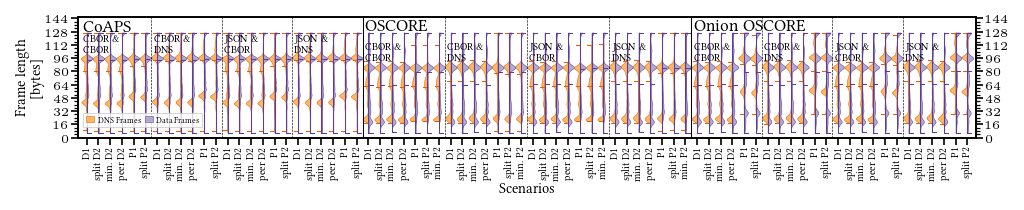

scenario,DNS lengths mean,DNS lengths min,DNS lengths q.25,DNS lengths median,DNS lengths q.75,DNS lengths max,data lengths mean,data lengths min,data lengths q.25,data lengths median,data lengths q.75,data lengths max
str,f64,i64,f64,f64,f64,i64,f64,i64,f64,f64,f64,i64
"""coaps-schc-d1_cbor_dns_cbor""",84.487085,6,73.0,84.0,98.0,127,99.977578,6,74.0,127.0,127.0,127
"""coaps-schc-d2_cbor_dns_cbor""",83.855763,6,72.0,83.0,97.0,127,99.937144,6,74.0,127.0,127.0,127
"""coaps-schc-d2-min-rules_cbor_d…",84.567302,6,73.0,84.0,98.0,127,100.002391,6,75.0,127.0,127.0,127
"""coaps-schc-d2-peer-based_cbor_…",84.100627,6,72.0,83.0,97.0,127,99.982762,6,75.0,127.0,127.0,127
"""coaps-schc-p1_cbor_dns_cbor""",88.022792,6,76.0,91.0,102.0,127,100.675821,6,77.0,127.0,127.0,127
"""coaps-schc-p2_cbor_dns_cbor""",87.054026,6,75.0,89.0,101.0,127,100.556303,6,78.0,127.0,127.0,127
"""coaps-schc-d1_cbor_dns_message""",96.363404,6,92.0,102.0,127.0,127,99.96005,6,74.0,127.0,127.0,127
"""coaps-schc-d2_cbor_dns_message""",96.438391,6,92.0,102.0,127.0,127,100.068845,6,75.0,127.0,127.0,127
"""coaps-schc-d2-min-rules_cbor_d…",95.902111,6,92.0,101.0,127.0,127,99.951026,6,74.0,127.0,127.0,127


#### [SCHC, Blocksize: 1024](plots/frame_lengths_schc_1024.pdf)

<Figure size 771.671x104.587 with 0 Axes>

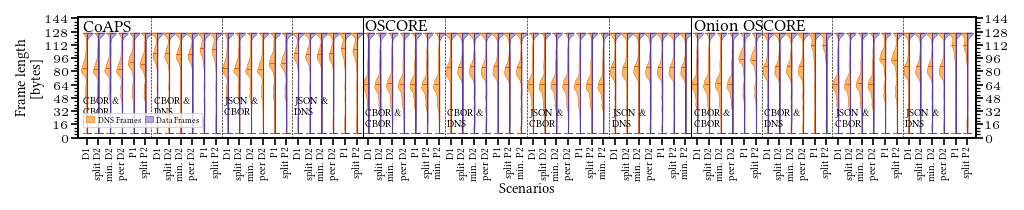

In [11]:
LINE_COLORS = ["#e66101",  "#5e3c99"]
# LINE_COLORS = matplotlib.colormaps["Dark2"].colors

for l2 in ["eth", "schc"]:
    for blocksize in [64, 1024]:
        matplotlib.pyplot.clf()
        matplotlib.style.use(str(EVALUATION_DIR / "mlenders_fullwidth.mplstyle"))
        matplotlib.rcParams["figure.figsize"] = (
            matplotlib.rcParams["figure.figsize"][0] * 1.14,
            matplotlib.rcParams["figure.figsize"][1] * 0.5,
        )
        fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
        matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
            "color",
            # https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4
            ["#fdb863", "#b2abd2"],
            #matplotlib.colormaps["Set2"].colors,
        )

        with polars.Config(tbl_rows=80):
            display(
                df.filter(
                    (polars.col("l2") == l2) & (polars.col("blocksize") == blocksize)
                ).select(
                    "scenario",
                    "DNS lengths mean",
                    "DNS lengths min",
                    "DNS lengths q.25",
                    "DNS lengths median",
                    "DNS lengths q.75",
                    "DNS lengths max",
                    "data lengths mean",
                    "data lengths min",
                    "data lengths q.25",
                    "data lengths median",
                    "data lengths q.75",
                    "data lengths max",
                )
            )
        violin_stats_dns = df.filter(
            (polars.col("l2") == l2) & (polars.col("blocksize") == blocksize)
        ).select(
            "scenario",
            "DNS lengths mean",
            "DNS lengths min",
            # "DNS lengths q.25",
            "DNS lengths median",
            # "DNS lengths q.75",
            "DNS lengths max",
            "DNS lengths violin coords",
            "DNS lengths violin vals",
        ).rename(
            {
                "scenario": "label",
                "DNS lengths mean": "mean",
                "DNS lengths min": "min",
                # "DNS lengths q.25": "q1",
                "DNS lengths median": "median",
                # "DNS lengths q.75": "q3",
                "DNS lengths max": "max",
                "DNS lengths violin coords": "coords",
                "DNS lengths violin vals": "vals",
            }
        )
        # .with_columns(
        #     quantiles=polars.concat_list("q1", "q3"),
        # )
        violin_stats_data = df.filter(
            (polars.col("l2") == l2) & (polars.col("blocksize") == blocksize)
        ).select(
            "scenario",
            "data lengths mean",
            "data lengths min",
            # "data lengths q.25",
            "data lengths median",
            # "data lengths q.75",
            "data lengths max",
            "data lengths violin coords",
            "data lengths violin vals",
        ).rename(
            {
                "scenario": "label",
                "data lengths mean": "mean",
                "data lengths min": "min",
                # "data lengths q.25": "q1",
                "data lengths median": "median",
                # "data lengths q.75": "q3",
                "data lengths max": "max",
                "data lengths violin coords": "coords",
                "data lengths violin vals": "vals",
            }
        )
        # .with_columns(
        #     quantiles=polars.concat_list("q1", "q3"),
        # )
        
        ax = matplotlib.pyplot.gca()
        
        dns_violin = ax.violin(
            violin_stats_dns.to_dicts(),
            widths=1,
            showmedians=True,
            showmeans=False,
            side="low",
        )
        data_violin = ax.violin(
            violin_stats_data.to_dicts(),
            widths=1,
            showmedians=True,
            showmeans=False,
            side="high",
        )

        for i, violin in enumerate([dns_violin, data_violin]):
            for lines in ["cbars", "cmins", "cmaxes", "cmedians"]:
                violin[lines].set_edgecolor(LINE_COLORS[i])
                violin[lines].set_linewidth(0.5)
                if lines in ("cmaxes", "cmins", "cmedians"):
                    segments = violin[lines].get_segments()
                    new_segments = []
                    for segment in segments:
                        if violin == dns_violin:
                            segment -= numpy.array([[0.1, 0], [0, 0]])
                        else:
                            segment += numpy.array([[0, 0], [0.1, 0]])
                        new_segments.append(segment)
                    violin[lines].set_segments(new_segments)
            for pc in violin['bodies']:
                pc.set_edgecolor(LINE_COLORS[i])
                pc.set_linewidth(0.25)
                pc.set_alpha(1)
        ax.set_xticks(
            *zip(*enumerate(violin_stats_dns["label"], start=1))
        )
        ax.set_xlim(0.3, violin_stats_dns.shape[0] + 0.7)
        ax.tick_params(axis='x', labelrotation=90)
        ax.set_xlabel("Scenarios")
        twin_ax = ax.twinx()
        axs = [ax, twin_ax]
        if l2 == "eth":
            for a in axs:
                a.set_ylim(0, 1260)
                a.set_yticks(numpy.arange(0, 1260, 128))
                a.set_yticks(numpy.arange(0, 1261, 32), minor=True)
        elif l2 == "schc":
            for a in axs:
                a.set_ylim(0, 146)
                a.set_yticks(numpy.arange(0, 146, 16))
                a.set_yticks(numpy.arange(0, 147, 4), minor=True)
        ax.set_ylabel("Frame length\n[bytes]")
        ax.legend(
            [dns_violin['bodies'][0], data_violin['bodies'][0]],
            ['DNS Frames', 'Data Frames'],
            loc="upper right" if l2 == "eth" else "lower left",
            bbox_to_anchor=(1.0, 0.8) if l2 == "eth" else (0.0, 0.05),
            # title="(min., max., and median marked)",
            # title_fontsize=4,
            fontsize=4,
            ncol=2,
        )
        mark_groups(
            ax,
            textalpha=1,
            format_offset={
                ("coaps", "schc", None): -35,
                ("oscore-base", "schc", None): -50,
                ("oscore", "schc", None): -50,
                ("coaps", "schc", "_b64"): 40,
                ("oscore-base", "schc", "_b64"): 30,
                ("oscore", "schc", "_b64"): 30,
            },
        )
        
        filename = EVALUATION_DIR / "plots" / f"frame_lengths_{l2}_{blocksize}.pdf"
        matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
        display(Markdown(f"#### [{L2_READABLE[l2]}, Blocksize: {blocksize}]({filename.relative_to(EVALUATION_DIR)})"))
        
        matplotlib.pyplot.show()

### Number of Frames

#### [Not constrained, Blocksize: 64](plots/frames_eth_64.pdf)

<Figure size 798.747x125.505 with 0 Axes>

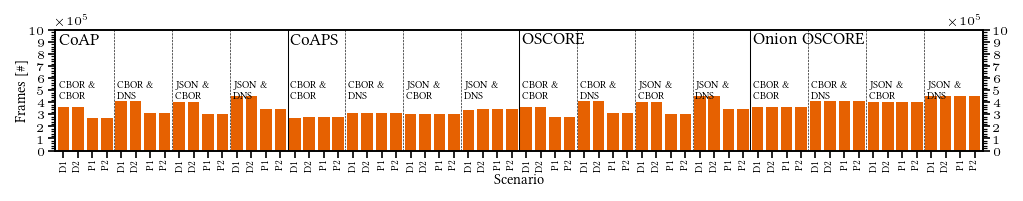

#### [Not constrained, Blocksize: 1024](plots/frames_eth_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

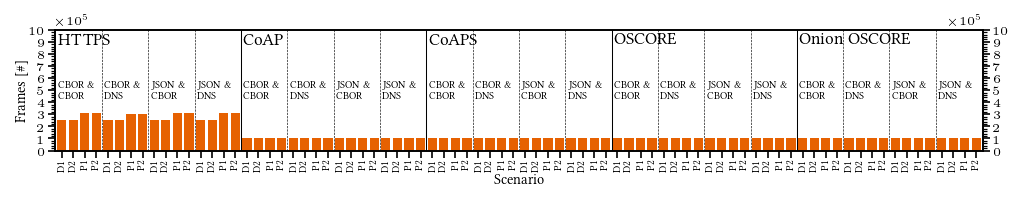

#### [SCHC, Blocksize: 64](plots/frames_schc_64.pdf)

<Figure size 798.747x104.587 with 0 Axes>

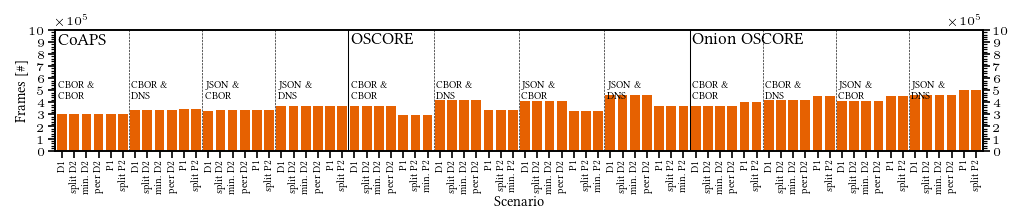

#### [SCHC, Blocksize: 1024](plots/frames_schc_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

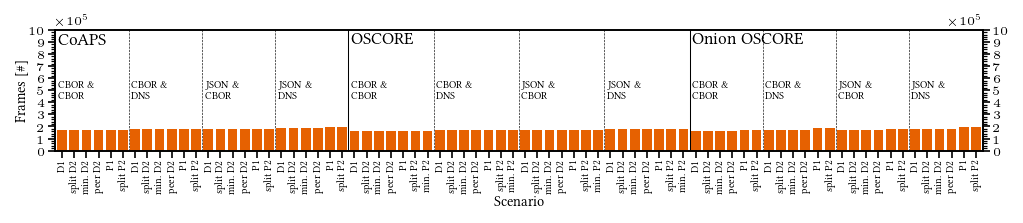

In [6]:
for l2 in ["eth", "schc"]:
    for blocksize in [64, 1024]:
        matplotlib.pyplot.clf()
        matplotlib.style.use(str(EVALUATION_DIR / "mlenders_fullwidth.mplstyle"))
        matplotlib.rcParams["figure.figsize"] = (
            matplotlib.rcParams["figure.figsize"][0] * 1.18,
            matplotlib.rcParams["figure.figsize"][1] * 0.5,
        )
        fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
        matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
            "color",
            # https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4
            ["#e66101", "#b2abd2"],
            #matplotlib.colormaps["Set2"].colors,
        )
        
        pltstats = df.filter(
            (polars.col("l2") == l2) & (polars.col("blocksize") == blocksize)
        )

        ax = matplotlib.pyplot.gca()
        ax.bar(pltstats["scenario"], pltstats["frames"])

        ax.set_xlim(-0.6, pltstats.shape[0] - 0.4)
        ax.tick_params(axis='x', labelrotation=90)
        ax.set_xlabel("Scenario")
        
        twin_ax = ax.twinx()
        axs = [ax, twin_ax]
        for a in axs:
            a.ticklabel_format(axis='y', style='sci', scilimits=(5,5))
            a.set_ylim(0, 1000000)
            a.set_yticks(numpy.arange(0, 1000001, 100000))
            a.set_yticks(numpy.arange(0, 1000001, 20000), minor=True)
            
        ax.set_ylabel(r"Frames [\#]")
            
        mark_groups(ax, textalpha=1, prot_offset=0.2e5)
        
        filename = EVALUATION_DIR / "plots" / f"frames_{l2}_{blocksize}.pdf"
        matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
        display(Markdown(f"#### [{L2_READABLE[l2]}, Blocksize: {blocksize}]({filename.relative_to(EVALUATION_DIR)})"))
        
        matplotlib.pyplot.show()

### Request vs. Response Frames

#### [Not constrained, Blocksize: 64](plots/req_resp_frames_eth_64.pdf)

<Figure size 798.747x104.587 with 0 Axes>

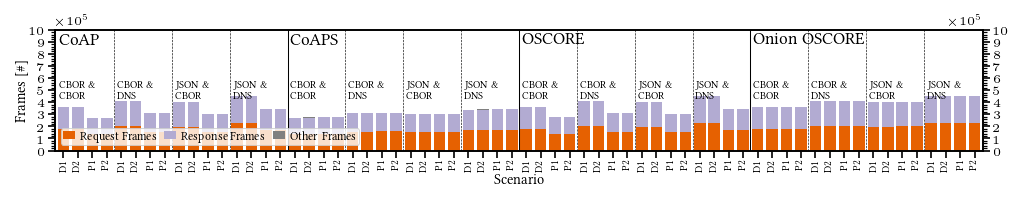

#### [Not constrained, Blocksize: 1024](plots/req_resp_frames_eth_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

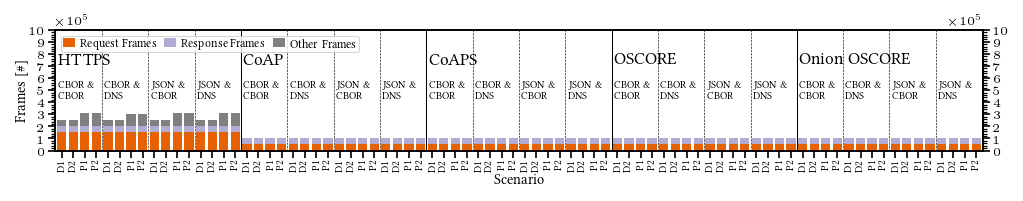

#### [SCHC, Blocksize: 64](plots/req_resp_frames_schc_64.pdf)

<Figure size 798.747x104.587 with 0 Axes>

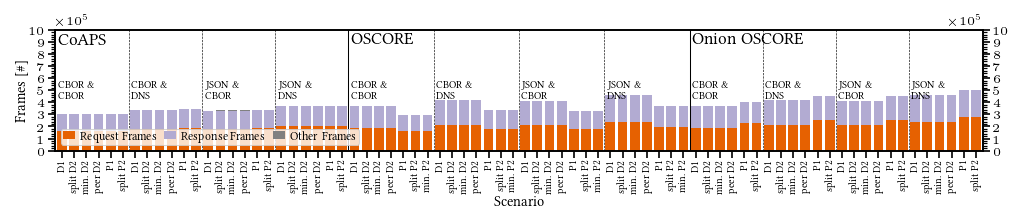

#### [SCHC, Blocksize: 1024](plots/req_resp_frames_schc_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

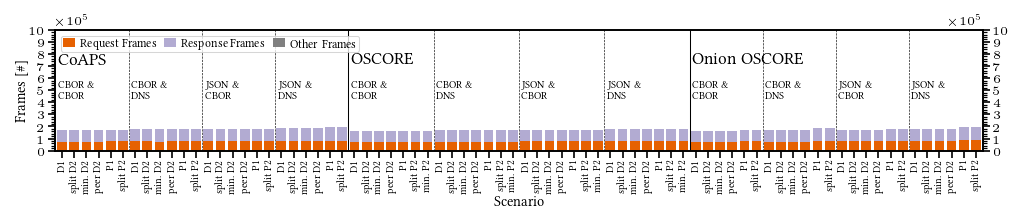

In [7]:
for l2 in ["eth", "schc"]:
    for blocksize in [64, 1024]:
        matplotlib.pyplot.clf()
        matplotlib.style.use(str(EVALUATION_DIR / "mlenders_fullwidth.mplstyle"))
        matplotlib.rcParams["figure.figsize"] = (
            matplotlib.rcParams["figure.figsize"][0] * 1.18,
            matplotlib.rcParams["figure.figsize"][1] * 0.5,
        )
        fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
        matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
            "color",
            # https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4
            ["#e66101", "#b2abd2"],
            #matplotlib.colormaps["Set2"].colors,
        )
        
        pltstats = df.filter(
            (polars.col("l2") == l2) & (polars.col("blocksize") == blocksize)
        )

        ax = matplotlib.pyplot.gca()
        ax.bar(pltstats["scenario"], pltstats["requests"], label="Request Frames")
        ax.bar(pltstats["scenario"], pltstats["responses"], label="Response Frames", bottom=pltstats["requests"])
        ax.bar(
            pltstats["scenario"],
            pltstats["frames"] - pltstats["requests"] - pltstats["responses"],
            label="Other Frames",
            bottom=pltstats["requests"] + pltstats["responses"],
            color="gray",
        )

        ax.set_xlim(-0.6, pltstats.shape[0] - 0.4)
        ax.tick_params(axis='x', labelrotation=90)
        ax.set_xlabel("Scenario")
        
        twin_ax = ax.twinx()
        axs = [ax, twin_ax]
        for a in axs:
            a.ticklabel_format(axis='y', style='sci', scilimits=(5,5))
            a.set_ylim(0, 1000000)
            a.set_yticks(numpy.arange(0, 1000001, 100000))
            a.set_yticks(numpy.arange(0, 1000001, 20000), minor=True)
            
        ax.set_ylabel(r"Frames [\#]")
        ax.legend(ncol=3, borderpad=0.2, loc=("upper left" if blocksize == 1024 else "lower left"))
        
        mark_groups(ax, textalpha=1, prot_offset=0.2e5 if blocksize == 64 else None)
        
        filename = EVALUATION_DIR / "plots" / f"req_resp_frames_{l2}_{blocksize}.pdf"
        matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
        display(Markdown(f"#### [{L2_READABLE[l2]}, Blocksize: {blocksize}]({filename.relative_to(EVALUATION_DIR)})"))
        
        matplotlib.pyplot.show()

### DNS vs. Data Frames

#### [Not constrained, Blocksize: 64](plots/dns_data_frames_eth_64.pdf)

<Figure size 798.747x104.587 with 0 Axes>

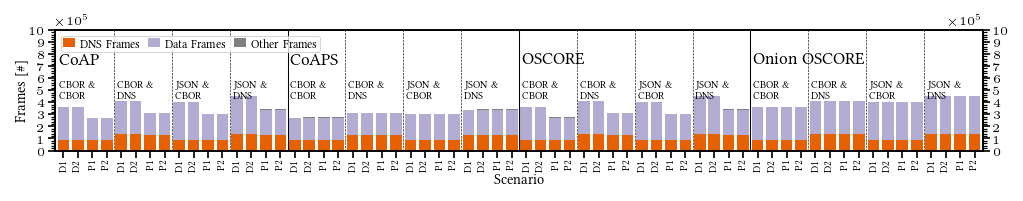

#### [Not constrained, Blocksize: 1024](plots/dns_data_frames_eth_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

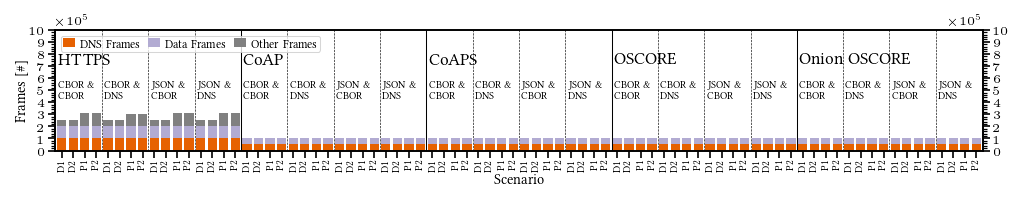

#### [SCHC, Blocksize: 64](plots/dns_data_frames_schc_64.pdf)

<Figure size 798.747x104.587 with 0 Axes>

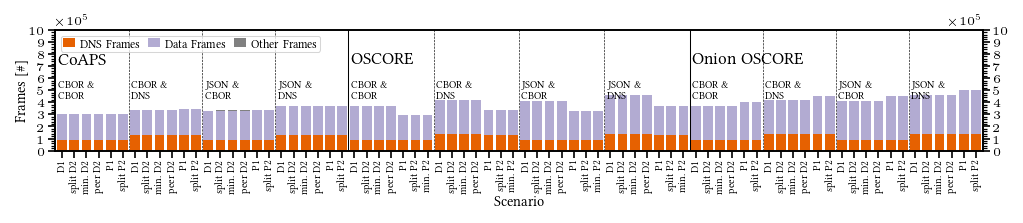

#### [SCHC, Blocksize: 1024](plots/dns_data_frames_schc_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

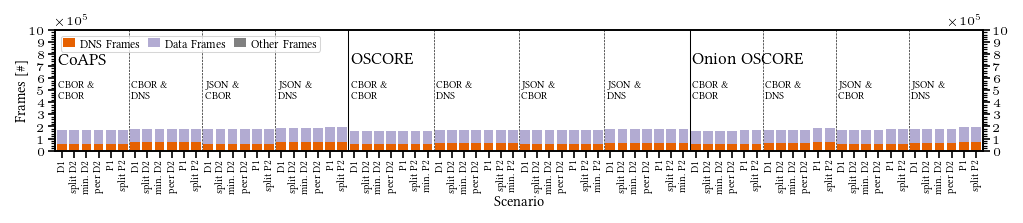

In [8]:
for l2 in ["eth", "schc"]:
    for blocksize in [64, 1024]:
        matplotlib.pyplot.clf()
        matplotlib.style.use(str(EVALUATION_DIR / "mlenders_fullwidth.mplstyle"))
        matplotlib.rcParams["figure.figsize"] = (
            matplotlib.rcParams["figure.figsize"][0] * 1.18,
            matplotlib.rcParams["figure.figsize"][1] * 0.5,
        )
        fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
        matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
            "color",
            ["#e66101", "#b2abd2"],
        )
        
        pltstats = df.filter(
            (polars.col("l2") == l2) & (polars.col("blocksize") == blocksize)
        )

        ax = matplotlib.pyplot.gca()
        ax.bar(pltstats["scenario"], pltstats["DNS frames"], label="DNS Frames")
        ax.bar(pltstats["scenario"], pltstats["data frames"], label="Data Frames", bottom=pltstats["DNS frames"])
        ax.bar(
            pltstats["scenario"],
            pltstats["frames"] - pltstats["DNS frames"] - pltstats["data frames"],
            label="Other Frames",
            bottom=pltstats["DNS frames"] + pltstats["data frames"],
            color="gray",
        )

        ax.set_xlim(-0.6, pltstats.shape[0] - 0.4)
        ax.tick_params(axis='x', labelrotation=90)
        ax.set_xlabel("Scenario")
        
        twin_ax = ax.twinx()
        axs = [ax, twin_ax]
        for a in axs:
            a.ticklabel_format(axis='y', style='sci', scilimits=(5,5))
            a.set_ylim(0, 1000000)
            a.set_yticks(numpy.arange(0, 1000001, 100000))
            a.set_yticks(numpy.arange(0, 1000001, 20000), minor=True)
        
        ax.set_ylabel(r"Frames [\#]")
        ax.legend(ncol=3, borderpad=0.2, loc="upper left")
        
        mark_groups(ax, textalpha=1)
        
        filename = EVALUATION_DIR / "plots" / f"dns_data_frames_{l2}_{blocksize}.pdf"
        matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
        display(Markdown(f"#### [{L2_READABLE[l2]}, Blocksize: {blocksize}]({filename.relative_to(EVALUATION_DIR)})"))
        
        matplotlib.pyplot.show()

### SCHC Fragments

#### [SCHC, Blocksize: 64](plots/schc_frames_schc_64.pdf)

<Figure size 798.747x104.587 with 0 Axes>

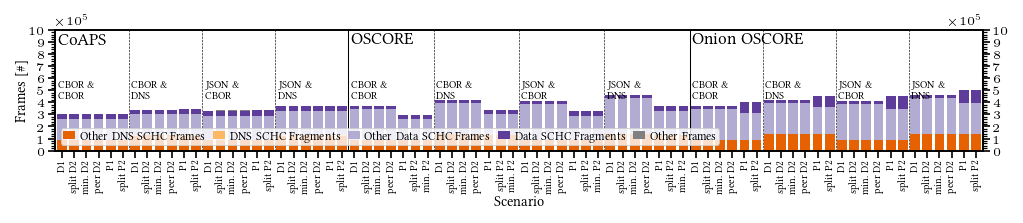

#### [SCHC, Blocksize: 1024](plots/schc_frames_schc_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

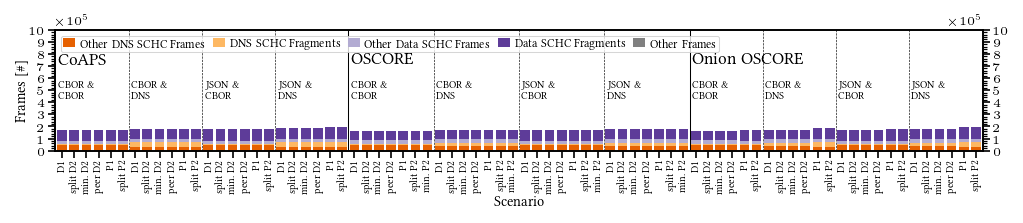

In [9]:
for l2 in ["schc"]:
    for blocksize in [64, 1024]:
        matplotlib.pyplot.clf()
        matplotlib.style.use(str(EVALUATION_DIR / "mlenders_fullwidth.mplstyle"))
        matplotlib.rcParams["figure.figsize"] = (
            matplotlib.rcParams["figure.figsize"][0] * 1.18,
            matplotlib.rcParams["figure.figsize"][1] * 0.5,
        )
        fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
        matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
            "color",
            # https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4
            ["#e66101", "#fdb863", "#b2abd2", "#5e3c99"]
            #matplotlib.colormaps["Set2"].colors,
        )
        
        pltstats = df.filter(
            (polars.col("l2") == l2) & (polars.col("blocksize") == blocksize)
        )

        ax = matplotlib.pyplot.gca()
        ax.bar(
            pltstats["scenario"],
            pltstats["DNS frames"] - pltstats["DNS SCHC fragments"],
            label="Other DNS SCHC Frames",
        )
        ax.bar(
            pltstats["scenario"],
            pltstats["DNS SCHC fragments"],
            label="DNS SCHC Fragments",
            bottom=pltstats["DNS frames"] - pltstats["DNS SCHC fragments"],
        )
        ax.bar(
            pltstats["scenario"],
            pltstats["data frames"] - pltstats["data SCHC fragments"],
            label="Other Data SCHC Frames",
            bottom=pltstats["DNS SCHC fragments"] + (pltstats["DNS frames"] - pltstats["DNS SCHC fragments"]),
        )
        ax.bar(
            pltstats["scenario"],
            pltstats["data SCHC fragments"],
            label="Data SCHC Fragments",
            bottom=pltstats["DNS SCHC fragments"] + (pltstats["DNS frames"] - pltstats["DNS SCHC fragments"]) + (pltstats["data frames"] - pltstats["data SCHC fragments"])
        )
        ax.bar(
            pltstats["scenario"],
            pltstats["frames"] - pltstats["DNS frames"] - pltstats["data frames"],
            label="Other Frames",
            bottom=pltstats["DNS frames"] + pltstats["data frames"],
            color="gray",
        )
        
        ax.set_xlim(-0.6, pltstats.shape[0] - 0.4)
        ax.tick_params(axis='x', labelrotation=90)
        ax.set_xlabel("Scenario")

        twin_ax = ax.twinx()
        axs = [ax, twin_ax]
        for a in axs:
            a.ticklabel_format(axis='y', style='sci', scilimits=(5,5))
            a.set_ylim(0, 1000000)
            a.set_yticks(numpy.arange(0, 1000001, 100000))
            a.set_yticks(numpy.arange(0, 1000001, 20000), minor=True)

        ax.set_ylabel(r"Frames [\#]")
        ax.legend(ncol=5, borderpad=0.2, loc=("upper left" if blocksize == 1024 else "lower left"))
        
        mark_groups(ax, textalpha=1, prot_offset=0.2e5 if blocksize == 64 else None)
        
        filename = EVALUATION_DIR / "plots" / f"schc_frames_{l2}_{blocksize}.pdf"
        matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
        display(Markdown(f"#### [{L2_READABLE[l2]}, Blocksize: {blocksize}]({filename.relative_to(EVALUATION_DIR)})"))
        
        matplotlib.pyplot.show()

### Blockwise Frames

#### [Not constrained, Blocksize: 64](plots/blockwise_frames_eth_64.pdf)

<Figure size 798.747x104.587 with 0 Axes>

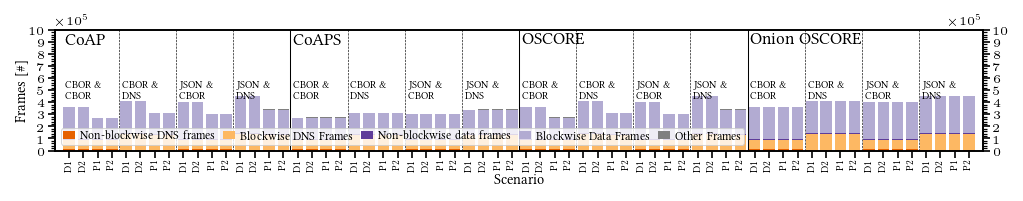

#### [Not constrained, Blocksize: 1024](plots/blockwise_frames_eth_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

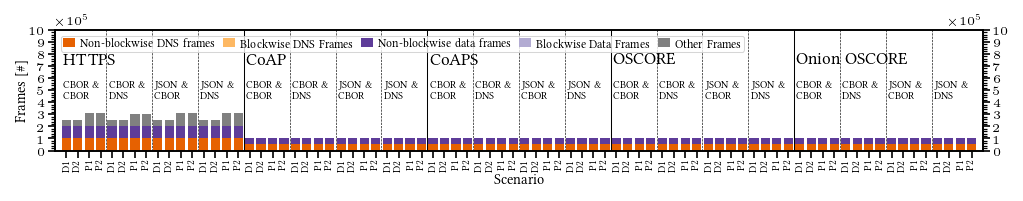

#### [SCHC, Blocksize: 64](plots/blockwise_frames_schc_64.pdf)

<Figure size 798.747x104.587 with 0 Axes>

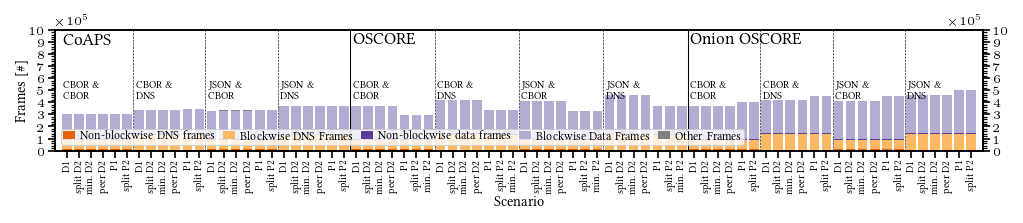

#### [SCHC, Blocksize: 1024](plots/blockwise_frames_schc_1024.pdf)

<Figure size 798.747x104.587 with 0 Axes>

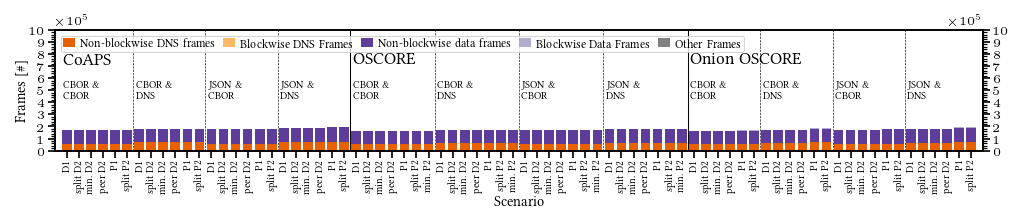

In [10]:
for l2 in ["eth", "schc"]:
    for blocksize in [64, 1024]:
        matplotlib.pyplot.clf()
        matplotlib.style.use(str(EVALUATION_DIR / "mlenders_fullwidth.mplstyle"))
        matplotlib.rcParams["figure.figsize"] = (
            matplotlib.rcParams["figure.figsize"][0] * 1.18,
            matplotlib.rcParams["figure.figsize"][1] * 0.5,
        )
        fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
        matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
            "color",
            # https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4
            ["#e66101", "#fdb863", "#5e3c99", "#b2abd2"]
            #matplotlib.colormaps["Set2"].colors,
        )

        pltstats = df.filter(
            (polars.col("l2") == l2) & (polars.col("blocksize") == blocksize)
        )

        ax = matplotlib.pyplot.gca()
        ax.bar(
            pltstats["scenario"],
            pltstats["DNS frames"] - pltstats["blockwise DNS frames"],
            label="Non-blockwise DNS frames",
        )
        ax.bar(
            pltstats["scenario"],
            pltstats["blockwise DNS frames"],
            label="Blockwise DNS Frames",
            bottom=pltstats["DNS frames"] - pltstats["blockwise DNS frames"],
        )
        ax.bar(
            pltstats["scenario"],
            pltstats["data frames"] - pltstats["blockwise data frames"],
            label="Non-blockwise data frames",
            bottom=pltstats["blockwise DNS frames"] + (
                pltstats["DNS frames"] - pltstats["blockwise DNS frames"]
            ),
        )
        ax.bar(
            pltstats["scenario"],
            pltstats["blockwise data frames"],
            label="Blockwise Data Frames",
            bottom=pltstats["blockwise DNS frames"] + (
                pltstats["DNS frames"] - pltstats["blockwise DNS frames"]
            ) + (
                pltstats["data frames"] - pltstats["blockwise data frames"]
            ),
        )
        ax.bar(
            pltstats["scenario"],
            pltstats["frames"] - pltstats["DNS frames"] - pltstats["data frames"],
            label="Other Frames",
            bottom=pltstats["DNS frames"] + pltstats["data frames"],
            color="gray",
        )

        ax.set_xlim(-1, pltstats.shape[0])
        ax.tick_params(axis='x', labelrotation=90)
        ax.set_xlabel("Scenario")

        twin_ax = ax.twinx()
        axs = [ax, twin_ax]
        for a in axs:
            a.ticklabel_format(axis='y', style='sci', scilimits=(5,5))
            a.set_ylim(0, 1000000)
            a.set_yticks(numpy.arange(0, 1000001, 100000))
            a.set_yticks(numpy.arange(0, 1000001, 20000), minor=True)

        ax.set_ylabel(r"Frames [\#]")
        ax.legend(ncol=5, borderpad=0.2, loc=("upper left" if blocksize == 1024 else "lower left"))
        
        mark_groups(ax, textalpha=1, prot_offset=0.2e5 if blocksize == 64 else None)
        
        filename = EVALUATION_DIR / "plots" / f"blockwise_frames_{l2}_{blocksize}.pdf"
        matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
        display(Markdown(f"#### [{L2_READABLE[l2]}, Blocksize: {blocksize}]({filename.relative_to(EVALUATION_DIR)})"))
        
        matplotlib.pyplot.show()

## Calculate Frame Length CDFs

In [11]:
def cdf_scenario(scenario, prot, l2, stp, l2_mode, data, dns, blk, _):
    try:
        eth_csv = INPUT_PATH / f"{scenario}.wpan.eth.csv.gz"
        training_csv = INPUT_PATH / f"{scenario}.training.csv.gz"
        lf = polars.scan_csv(eth_csv, separator="\t").with_columns(
            (polars.col("eth.payload").str.len_chars() // 2).alias("eth.payload length"),
        ).join(
            polars.scan_csv(training_csv, separator=";").select(
                ["frame.number", "client.type"]
            ),
            on="frame.number",
            how="left",
        ).select("eth.payload length", "client.type").with_columns(
            polars.col("client.type").fill_null("other")
        )
        df = polars.DataFrame(
            [
                {
                    "protocol": prot, 
                    "l2": "schc" if l2 == "-schc" else "eth",
                    "setup": stp[0],
                    "dns_format": dns,
                    "blocksize": 64 if blk else 1024,
                    "type": typ,
                    "X": lf.filter(
                        polars.col("client.type") == typ
                    ).collect()["eth.payload length"].to_list(),
                }
                for typ, in lf.select("client.type").unique().collect().rows()
            ]
        ).cast({"X": polars.List(polars.Int16)})
        return df
    except Exception as exc:
        print(exc, file=sys.stderr)
        sys.stderr.flush()
        raise


res = None

workers = multiprocessing.cpu_count()

if workers > 96:
    workers = 96


scenarios = list(list_scenarios_full(filter_randiv_pad=True))


with concurrent.futures.ProcessPoolExecutor(max_workers=workers) as pool:
    def _cdf_scenario(args):
        return cdf_scenario(*args)
    for df in tqdm(pool.map(_cdf_scenario, scenarios), total=len(scenarios)):
        if res is None:
            res = df
        else:
            new = polars.concat([res, df])
            del res
            del df
            res = new
res = res.group_by(["l2", "setup", "protocol", "blocksize", "dns_format", "type"]).agg(
    polars.col("X").flatten().sort()
).with_columns(
    N=polars.col("X").list.len()
).with_columns(
    CDF=polars.int_ranges(end="N") / polars.col("N")
).cast({"CDF": polars.List(polars.Float32)}).select(res.columns + ["CDF"]).sort(
    ["l2", "blocksize", "setup", "protocol", "dns_format", "type"]
).select(["l2", "blocksize", "protocol", "setup", "dns_format", "type", "X", "CDF"])
display(res)
res.write_parquet(INPUT_PATH / "length_cdfs.parquet", compression="lz4")
del res

  0%|          | 0/296 [00:00<?, ?it/s]

l2,blocksize,protocol,setup,dns_format,type,X,CDF
str,i64,str,str,str,str,list[i16],list[f32]
"""eth""",64,"""coap""","""d""","""dns_cbor""","""data""","[57, 57, … 693]","[0.0, 5.0461e-7, … 1.0]"
"""eth""",64,"""coap""","""d""","""dns_cbor""","""dns""","[57, 57, … 140]","[0.0, 0.000001, … 0.999999]"
"""eth""",64,"""coap""","""d""","""dns_message""","""data""","[57, 57, … 693]","[0.0, 5.0461e-7, … 1.0]"
"""eth""",64,"""coap""","""d""","""dns_message""","""dns""","[57, 57, … 141]","[0.0, 7.5873e-7, … 0.999999]"
"""eth""",64,"""coaps""","""d""","""dns_cbor""","""data""","[87, 87, … 1121]","[0.0, 6.1495e-7, … 0.999999]"
…,…,…,…,…,…,…,…
"""schc""",1024,"""oscore-base""","""p""","""dns_cbor""","""dns""","[6, 6, … 127]","[0.0, 0.000001, … 0.999999]"
"""schc""",1024,"""oscore-base""","""p""","""dns_cbor""","""other""","[3, 3, … 127]","[0.0, 0.000068, … 0.999932]"
"""schc""",1024,"""oscore-base""","""p""","""dns_message""","""data""","[6, 6, … 127]","[0.0, 7.8644e-7, … 0.999999]"


## Load Pre-calculated Length CDFs

In [12]:
df = polars.read_parquet(INPUT_PATH / "length_cdfs.parquet")

## Plot Length CDFs

#### [Not constrained, Blocksize: 64](plots/cdf_length_eth_64.pdf)

<Figure size 778.44x104.587 with 0 Axes>

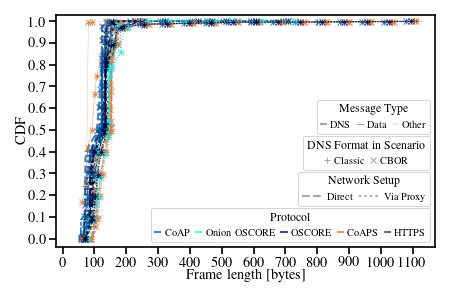

#### [Not constrained, Blocksize: 1024](plots/cdf_length_eth_1024.pdf)

<Figure size 325.949x201.448 with 0 Axes>

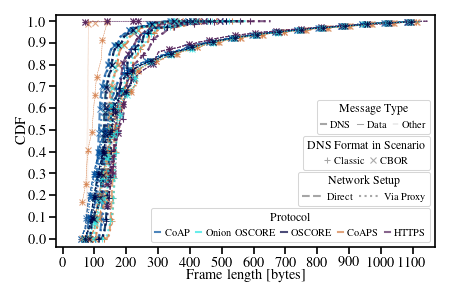

#### [SCHC, Blocksize: 64](plots/cdf_length_schc_64.pdf)

<Figure size 325.949x201.448 with 0 Axes>

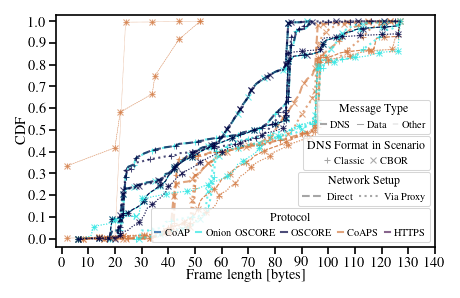

#### [SCHC, Blocksize: 1024](plots/cdf_length_schc_1024.pdf)

<Figure size 325.949x201.448 with 0 Axes>

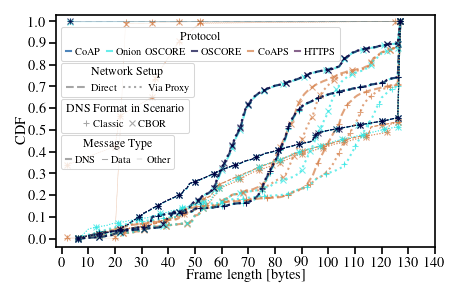

In [13]:
COLORS = ["#28e6e3", "#02519e", "#000040", "#54225b", "#d47c45"]
L2_READABLE = {
    "eth": "Not constrained",
    "schc": "SCHC",
}
PROTOCOLS_READABLE = {
    "coap": "CoAP",
    "coaps": "CoAPS",
    "https": "HTTPS",
    "oscore-base": "OSCORE",
    "oscore": "Onion OSCORE",
}
SETUP_READABLE = {
    "d": "Direct",
    "p": "Via Proxy",
}
DNS_FORMAT_READABLE = {
    "dns_message": r"Classic",
    "dns_cbor": r"CBOR",
}
TYPE_READABLE = {
    "dns": "DNS",
    "data": "Data",
    "other": "Other",
}
PROT_STYLE = {
    "coap": {"color": "C1"},
    "oscore": {"color": "C0"},
    "oscore-base": {"color": "C2"},
    "coaps": {"color": "C4"},
    "https": {"color": "C3"},
}
SETUP_STYLE = {
    "d": {"linestyle": "--"},
    "p": {"linestyle": ":"},
}
DNS_FORMAT_STYLE = {
    "dns_message": {"marker": "+"},
    "dns_cbor": {"marker": "x"},
}
TYPE_STYLE = {
    "dns": {"linewidth": 1},
    "data": {"linewidth": 0.5},
    "other": {"linewidth": 0.2},
}
ALPHA = 0.7

for l2 in ["eth", "schc"]:
    for blocksize in [64, 1024]:
        matplotlib.pyplot.clf()
        matplotlib.style.use(str(EVALUATION_DIR / "mlenders_column.mplstyle"))
        matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
            "color",
            COLORS,
        )
        matplotlib.rcParams["figure.figsize"] = (
            matplotlib.rcParams["figure.figsize"][0],
            matplotlib.rcParams["figure.figsize"][1] * 2,
        )
        fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
        
        ax = matplotlib.pyplot.gca()

        for prot, stp, dns, typ, X, CDF in df.filter(
            (polars.col("l2") == l2)
            & (polars.col("blocksize") == blocksize)
        ).select("protocol", "setup", "dns_format", "type", "X", "CDF").rows():
            cdf_df = polars.DataFrame({"X": X, "CDF": CDF})
            del X
            del CDF
            cdf_df = cdf_df.unique("X", keep="last").sort("X")
            ax.plot(
                cdf_df["X"],
                cdf_df["CDF"],
                alpha=ALPHA,
                markevery=0.05,
                **PROT_STYLE[prot],
                **SETUP_STYLE[stp],
                **DNS_FORMAT_STYLE[dns],
                **TYPE_STYLE[typ],
            )
            del cdf_df

        ax.set_xlabel("Frame length [bytes]")
        if l2 == "eth":
            ax.set_xlim(-20, 1170)
            ax.set_xticks(numpy.arange(0, 1170, 100))
        else:
            ax.set_xlim(-2, 133)
            ax.set_xticks(numpy.arange(0, 143, 10))
        ax.set_ylabel("CDF")
        ax.set_ylim(-0.04, 1.03)
        ax.set_yticks(numpy.arange(0, 1.02, 0.1))

        for title, style, labels, bbox_to_anchor, ncol in [
            ("Message Type", TYPE_STYLE, TYPE_READABLE, numpy.array([1.0, 0.465]), 3),
            ("DNS Format in Scenario", DNS_FORMAT_STYLE, DNS_FORMAT_READABLE, numpy.array([1.0, 0.310]), 2),
            ("Network Setup", SETUP_STYLE, SETUP_READABLE, numpy.array([1.0, 0.155]), 2),
            ("Protocol", PROT_STYLE, PROTOCOLS_READABLE, numpy.array([1.0, 0.000]), 5),
        ]:
            color = {}
            linewidth = {}
            if all("color" not in d for d in style.values()):
                if any("marker" in d for d in style.values()):
                    linewidth = {"linewidth": 0}
                color = {"color": "gray"}
            legend_handles = (
                [
                    (
                        matplotlib.lines.Line2D(
                            [0],
                            [0],
                            alpha=ALPHA,
                            **color,
                            **linewidth,
                            **style[prot],
                        ),
                        labels[prot],
                    )
                    for prot in style
                ]
            )
            legend = ax.legend(
                *zip(*legend_handles),
                loc=(
                    "lower right"
                    if l2 != "schc" or blocksize != 1024
                    else "upper left"
                ),
                bbox_to_anchor=(
                    bbox_to_anchor
                    if l2 != "schc" or blocksize != 1024
                    else numpy.array([1.0, 0.97]) - bbox_to_anchor
                ),
                ncol=ncol,
                fontsize=5,
                handlelength=(
                    0.5 
                    if all("linestyle" not in d for d in style.values())
                    else 2.0
                ),
                title=title,
                title_fontsize="xx-small",
            )
            if title != "Protocol":
                ax.add_artist(legend)
            
        filename = EVALUATION_DIR / "plots" / f"cdf_length_{l2}_{blocksize}.pdf"
        matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
        display(Markdown(f"#### [{L2_READABLE[l2]}, Blocksize: {blocksize}]({filename.relative_to(EVALUATION_DIR)})"))
        
        matplotlib.pyplot.show()